In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, minimize

In [ ]:
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)
EPS = 1e-6

In [ ]:
#Data & Preprocessing
URL = "https://raw.githubusercontent.com/owid/monkeypox/main/owid-monkeypox-data.csv"
df_full = pd.read_csv(URL, parse_dates=["date"])

df_full = (df_full[df_full["location"] == "World"][["date", "total_cases", "total_deaths"]]
      .drop_duplicates()
      .sort_values("date")
      .reset_index(drop=True))

df_full[["total_cases", "total_deaths"]] = df_full[["total_cases", "total_deaths"]].fillna(0.0)

df_full.columns = ["date", "cases_cum", "deaths_cum"]
df_full = df_full.set_index("date").resample("D").interpolate("linear").reset_index()

cases_cum_full  = df_full["cases_cum"].to_numpy(float)
deaths_cum_full = df_full["deaths_cum"].to_numpy(float)

In [4]:
print(f"   Period : {df_full['date'].iloc[0].date()} -> {df_full['date'].iloc[-1].date()}")
print(f"   Days   : {len(df_full)}")
print(f"   Total cases  : {cases_cum_full[-1]:.0f}")
print(f"   Total deaths : {deaths_cum_full[-1]:.0f}")

   Period : 2022-05-01 -> 2026-01-26
   Days   : 1367
   Total cases  : 175692
   Total deaths : 483


In [ ]:
# Windowing based on 7-day smoothed daily cases
new_cases = np.diff(cases_cum_full, prepend=cases_cum_full[0])
new_cases = np.maximum(new_cases, 0.0)

# 7-day centered rolling average to fix weekend reporting lags
new_cases_smooth = pd.Series(new_cases).rolling(7, center=True, min_periods=1).mean().to_numpy()

# Epidemiological peak
peak_idx_global = int(np.argmax(new_cases_smooth))

# Window: 30 days before peak -> 180 days after
start_idx = max(peak_idx_global - 30, 0)
end_idx   = min(peak_idx_global + 180, len(df_full))


df_win = df_full.iloc[start_idx:end_idx].reset_index(drop=True)
cases_cum  = df_win["cases_cum"].to_numpy(float)
deaths_cum = df_win["deaths_cum"].to_numpy(float)
N_days = len(df_win)

In [6]:
print("\nWindowed data for fitting (Acute Phase)")
peak_in_window = peak_idx_global - start_idx
print(f"   Peak new cases day: {df_win['date'].iloc[peak_in_window].date()}")
print(f"   Window : {df_win['date'].iloc[0].date()} -> {df_win['date'].iloc[-1].date()}")
print(f"   Days   : {N_days}")


Windowed data for fitting (Acute Phase)
   Peak new cases day: 2022-07-30
   Window : 2022-06-30 -> 2023-01-25
   Days   : 210


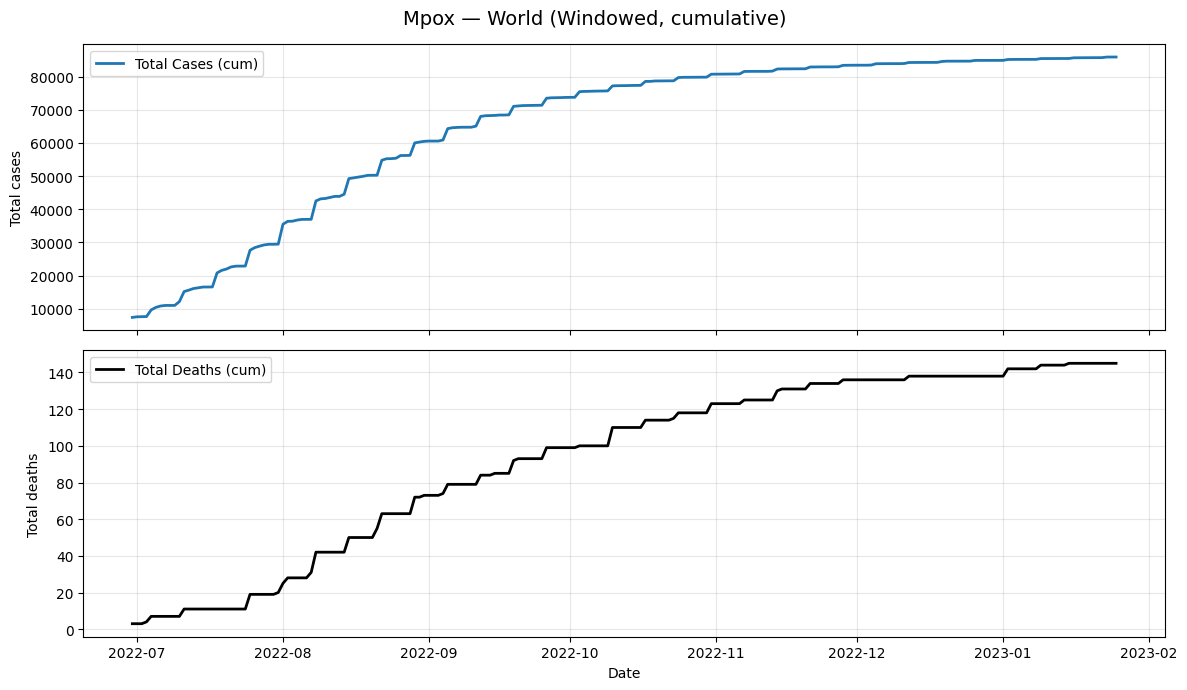

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df_win["date"], cases_cum, linewidth=2, label="Total Cases (cum)")
axes[0].set_ylabel("Total cases")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_win["date"], deaths_cum, linewidth=2, color="black", label="Total Deaths (cum)")
axes[1].set_ylabel("Total deaths")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("Mpox — World (Windowed, cumulative)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# SEIRDC ODE (C = cumulative infections)
def seirdc_rhs(t, y, beta, alpha, gamma, mu, N):
    S, E, I, R, D, C = y

    S = max(S, 0.0)
    E = max(E, 0.0)
    I = max(I, 0.0)

    foi = beta * S * I / N

    dS = -foi
    dE = foi - alpha * E
    dI = alpha * E - (gamma + mu) * I
    dR = gamma * I
    dD = mu * I
    dC = alpha * E

    return [dS, dE, dI, dR, dD, dC]

def rollout(params_vec, rtol=1e-4, atol=1e-7):
    beta, alpha, gamma, mu, N, E0_frac = params_vec

    C0 = float(cases_cum[0])
    D0 = float(deaths_cum[0])
    I0 = 1.0
    E0 = float(E0_frac * N)
    R0 = max(C0 - I0 - D0, 0.0)
    S0 = max(N - E0 - I0 - R0 - D0, 1.0)

    y0 = [S0, E0, I0, R0, D0, C0]

    sol = solve_ivp(
        fun=lambda t, y: seirdc_rhs(t, y, beta, alpha, gamma, mu, N),
        t_span=(0.0, float(N_days - 1)),
        y0=y0,
        t_eval=np.arange(N_days, dtype=float),
        method="RK45",
        rtol=rtol,
        atol=atol,
    )

    if (not sol.success) or (sol.y.shape[1] != N_days):
        return None

    D = np.maximum(sol.y[4, :], 0.0)
    C = np.maximum(sol.y[5, :], 0.0)

    if not (np.all(np.isfinite(D)) and np.all(np.isfinite(C))):
        return None

    return C, D

In [ ]:
# Loss (log-space) on C and D
def loss_fast(params_vec):
    beta, alpha, gamma, mu, N, E0_frac = params_vec

    if not (0.01 <= beta  <= 3.0 and
            0.07 <= alpha <= 0.2 and
            0.04 <= gamma <= 0.15 and
            0.00001 <= mu <= 0.05 and
            1e5 <= N <= 2e9 and
            0.001 <= E0_frac <= 0.05):
        return 1e9

    out = rollout(params_vec, rtol=1e-4, atol=1e-7)
    if out is None:
        return 1e9

    C_model, D_model = out

    errC = np.log(C_model + EPS) - np.log(cases_cum + EPS)
    errD = np.log(D_model + EPS) - np.log(deaths_cum + EPS)

    return float(np.mean(errC**2) + np.mean(errD**2))

bounds = [
    (0.01, 3.0),      # beta
    (0.07, 0.2),      # alpha -> 5-14 days (realistic)
    (0.04, 0.15),     # gamma -> 7-25 days  
    (1e-5, 0.05),     # mu
    (1e5, 2e9),       # N (effective susceptible pool)
    (0.001, 0.05),    # E0_frac
]

best_state = {"f": np.inf, "stall": 0}
def cb(xk, convergence):
    fx = loss_fast(xk)
    if fx + 1e-6 < best_state["f"]:
        best_state["f"] = fx
        best_state["stall"] = 0
    else:
        best_state["stall"] += 1
    return best_state["stall"] >= 10

de = differential_evolution(
    func=loss_fast,
    bounds=bounds,
    seed=42,
    maxiter=120,
    popsize=6,
    tol=1e-3,
    mutation=(0.4, 0.9),
    recombination=0.7,
    polish=False,
    updating="immediate",
    workers=1,
    disp=True,
    callback=cb
)

print("\nDE done, loss:", float(de.fun))

print("\nLocal polish (L-BFGS-B)...")
local = minimize(
    loss_fast,
    de.x,
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 300}
)

best = local.x
best_loss = float(local.fun)
beta_f, alpha_f, gamma_f, mu_f, N_f, E0_frac_f = best

print(f"\nBest loss = {best_loss:.6f}")
print(f"   beta  = {beta_f:.4f}")
print(f"   alpha = {alpha_f:.4f}  (incubation ≈ {1/alpha_f:.2f} days)")
print(f"   gamma = {gamma_f:.4f}  (infectious ≈ {1/gamma_f:.2f} days)")
print(f"   mu    = {mu_f:.6f}")
print(f"   N     = {N_f:.0f}")
print(f"   E0    = {E0_frac_f*N_f:.0f}")
print(f"   R0_eff= {beta_f/(gamma_f+mu_f):.3f}")

out = rollout(best, rtol=1e-6, atol=1e-9)
if out is None:
    raise RuntimeError("Final rollout failed; loosen tolerances slightly.")
C_roll, D_roll = out

differential_evolution step 1: f(x)= 117.64168352484722
differential_evolution step 2: f(x)= 80.93683992915487
differential_evolution step 3: f(x)= 80.93683992915487
differential_evolution step 4: f(x)= 80.93683992915487
differential_evolution step 5: f(x)= 73.60984049100288
differential_evolution step 6: f(x)= 73.60984049100288
differential_evolution step 7: f(x)= 73.60984049100288
differential_evolution step 8: f(x)= 73.60984049100288
differential_evolution step 9: f(x)= 73.60984049100288
differential_evolution step 10: f(x)= 73.60984049100288
differential_evolution step 11: f(x)= 22.74796536942352
differential_evolution step 12: f(x)= 15.350791340610506
differential_evolution step 13: f(x)= 15.350791340610506
differential_evolution step 14: f(x)= 13.404239493189813
differential_evolution step 15: f(x)= 13.404239493189813
differential_evolution step 16: f(x)= 7.367413929218825
differential_evolution step 17: f(x)= 4.324815847587448
differential_evolution step 18: f(x)= 4.324815847587

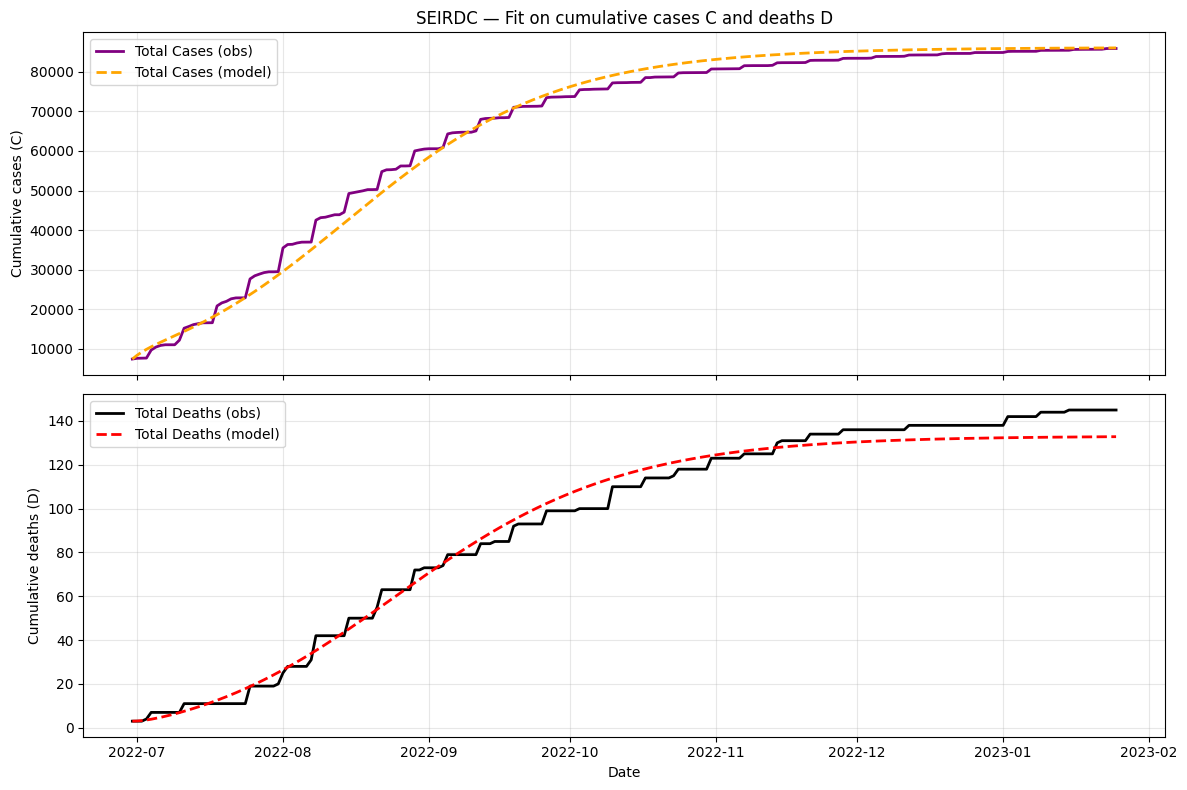

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_win["date"], cases_cum, linewidth=2, label="Total Cases (obs)", color="purple")
axes[0].plot(df_win["date"], C_roll, "--", linewidth=2, label="Total Cases (model)", color="orange")
axes[0].set_ylabel("Cumulative cases (C)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("SEIRDC — Fit on cumulative cases C and deaths D")

axes[1].plot(df_win["date"], deaths_cum, linewidth=2, label="Total Deaths (obs)", color="black")
axes[1].plot(df_win["date"], D_roll, "--", linewidth=2, label="Total Deaths (model)", color="red")
axes[1].set_ylabel("Cumulative deaths (D)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

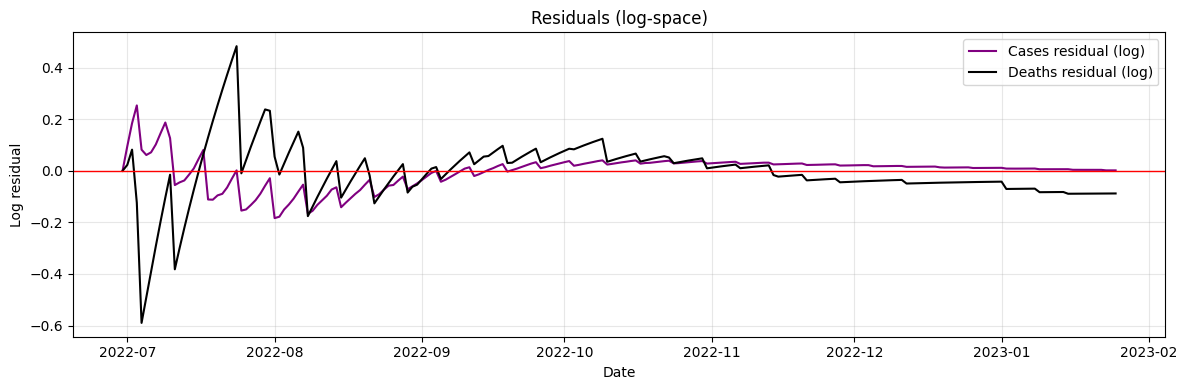


Final Report:
   Cases log-RMSE  : 0.0605
   Deaths log-RMSE : 0.1158
   R0 (basic repro): 1.913
   Incubation ≈ 5.10 days, Infectious ≈ 11.22 days
   CFR (model) ≈ 0.17%


In [ ]:
# Residuals

resC = np.log(C_roll + EPS) - np.log(cases_cum + EPS)
resD = np.log(D_roll + EPS) - np.log(deaths_cum + EPS)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_win["date"], resC, label="Cases residual (log)", color="purple")
ax.plot(df_win["date"], resD, label="Deaths residual (log)", color="black")
ax.axhline(0, color="red", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Log residual")
ax.set_title("Residuals (log-space)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rmse_C = float(np.sqrt(np.mean(resC**2)))
rmse_D = float(np.sqrt(np.mean(resD**2)))

print(f"\nFinal Report:")
print(f"   Cases log-RMSE  : {rmse_C:.4f}")
print(f"   Deaths log-RMSE : {rmse_D:.4f}")
print(f"   R0 (basic repro): {beta_f/(gamma_f+mu_f):.3f}")
print(f"   Incubation ≈ {1/alpha_f:.2f} days, Infectious ≈ {1/gamma_f:.2f} days")
print(f"   CFR (model) ≈ {mu_f/(gamma_f+mu_f)*100:.2f}%")